# Plot time-height updraft samples for narrow vs. wide cells
## Use pre-computed updraft 2D mask files (make_largest_updraft_stats.py)

In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
# Specify domain name (d2, d3, d4)
domain_name = 'd4'
# domain_name = 'd4_5min_2.5km'
resolution = 'les'  # 'les' or 'meso'

# figdir = f'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/{resolution}/figures_avgenv20km/updraft_tracks_narrowwide/'
figdir = '/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/'
# figdir = '/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min_regrid2.5km/'
os.makedirs(figdir, exist_ok=True)

# input_dir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/cell_stats_combined_coldpool+2h'
input_dir = '/Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min'

# Load D4 domain
# file_d4 = f'{input_dir}/stats_combined_filtered_d4.nc'
file_d4 = f'{input_dir}/stats_combined_filtered_{domain_name}.nc'
print(f"Loading: {file_d4}")
# 
ds_dx = xr.open_dataset(file_d4).load()
ntracks_nms_d4 = ds_dx.sizes['tracks']
print(f"  D4 filtered tracks: {ntracks_nms_d4}")

# Display memory usage
mem_dx = sum(var.nbytes for var in ds_dx.variables.values()) / 1e9
print(f"\nMemory usage: {mem_dx:.2f} GB")

Loading: /Users/feng045/data/cacti/lasso/les/cell_stats_combined_CI30min/stats_combined_filtered_d4.nc


/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  D4 filtered tracks: 1202

Memory usage: 0.93 GB


## Find merge/split tracks

In [3]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_dx.times * time_res
height = ds_dx.z / 1000.

# Limit of updraft sampling end period after CI
W_CI_time_end = 30.  # [min]

In [4]:
def find_merge_split_tracks(ds, time_window):
    """
    Find merge/split track indices.
    """
    # Get track lifetime
    lifetime = ds.track_duration.load() * time_res

    # Non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())

    # Non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())

    # Merge after time window tracks
    idx_merge_after = ~np.isnan(ds.end_merge_cloudnumber.load()) & (lifetime > np.max(time_window))

    # Combine conditions (satisfy both):
    # - Non-merge or merge after time window
    # - Non-split
    idx_nms = np.logical_and(idx_nsplit, (np.logical_or(idx_nmerge, idx_merge_after)))

    # Group outputs to dictionary
    out_dict = {
        'ns': idx_nsplit,
        'nm': idx_nmerge,
        'ms': idx_merge_after,
        'nms': idx_nms,
    }
    return out_dict

## Subset DataSets with non-merge/non-split tracks

In [5]:
time_window = (ds_dx.attrs['time_start'], ds_dx.attrs['time_end'])
print(time_window)
tid_dx = find_merge_split_tracks(ds_dx, time_window)

(np.int64(0), np.int64(60))


In [6]:
dsnms_dx = ds_dx.isel(tracks=tid_dx['nms'])

# Get number of tracks
ntracks_nms_dx = dsnms_dx.sizes['tracks']
print(f'{domain_name} non-merge-split tracks: {ntracks_nms_dx}')

d4 non-merge-split tracks: 1202


In [7]:
# Get some constents common for all Datasets
ntimes = dsnms_dx.sizes['times']
nz = dsnms_dx.sizes['z']
# ncores = dsnms_dx.sizes['core']
time_coord = dsnms_dx.times
xtime = time_coord * time_res  # [min]

# Find time coordinate index of the time_window
tidx_start = np.abs(xtime - np.min(time_window)).argmin().item()
tidx_end = np.abs(xtime - np.max(time_window)).argmin().item()
tidx_start, tidx_end

/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/Users/feng045/opt/miniconda3/envs/py312-26.4/lib/python3.12/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


(0, 12)

## Subset cell area/ETH stats to **CI time window** and get their CI-period max values

In [8]:
# Subset DataSet to CI time_window
dsCI_dx = dsnms_dx.isel(times=slice(tidx_start, tidx_end))

# Cell max reflectivity
maxdbz_dx = dsCI_dx['max_dbz'].load()
# Cell ETH
maxETH_10dbz_dx = dsCI_dx['maxETH_10dbz'].load()
# Cell diameter
cellarea_dx = dsCI_dx['cell_area'].load()
celldiam_dx = 2 * np.sqrt(cellarea_dx / np.pi)
# Max updraft top height
trackmaxWtop_dx = dsCI_dx.Wtop.max(dim='times')
# Calculate max W diameter (Warea_max has no times dimension)
maxWdiam_dx = 2*np.sqrt(dsCI_dx.Warea_max/np.pi)

## Get **CI-max** 10dBZ ETH and cell diameter percentile values

In [9]:
trackmaxETH_10dbz_dx = maxETH_10dbz_dx.max(dim='times')
trackmaxCellDiam_dx = celldiam_dx.max(dim='times')
trackmaxdbz_dx = maxdbz_dx.max(dim='times')

In [10]:
# Add CI-period variables to DataSet
dsnms_dx['CImaxCellDiam'] = trackmaxCellDiam_dx
dsnms_dx['CImaxETH_10dbz'] = trackmaxETH_10dbz_dx
dsnms_dx['CImaxdbz'] = trackmaxdbz_dx
dsnms_dx['CImaxWDiam'] = maxWdiam_dx

## Separate narrow vs. wide cell DataSets

In [ ]:
# if (domain_name == 'd2'): narrow_diam_dx = 12.93  # km 
# if (domain_name == 'd3'): narrow_diam_dx = 7.05  # km  
# if (domain_name == 'd4'): narrow_diam_dx = 7.44  # km

# if (domain_name == 'd2'): wide_diam_dx = 15.71  # km
# if (domain_name == 'd3'): wide_diam_dx = 9.10  # km
# if (domain_name == 'd4'): wide_diam_dx = 8.97  # km

In [11]:
if (domain_name == 'd2'): narrow_diam_dx = 12.71  # km 
if (domain_name == 'd3'): narrow_diam_dx = 7.36  # km  
if (domain_name == 'd4'): narrow_diam_dx = 7.33  # km

if (domain_name == 'd2'): wide_diam_dx = 15.71  # km
if (domain_name == 'd3'): wide_diam_dx = 8.65  # km
if (domain_name == 'd4'): wide_diam_dx = 8.80  # km

In [12]:
# # For regridded 2.5 km data
# if domain_name == 'd2': narrow_diam_dx = 12.6156625748  # km
# if domain_name == 'd3_5min_2.5km': narrow_diam_dx = 12.9272069931  # km
# if domain_name == 'd4_5min_2.5km': narrow_diam_dx = 12.9272069931  # km

# if domain_name == 'd2': wide_diam_dx = 15.7063732147  # km
# if domain_name == 'd3_5min_2.5km': wide_diam_dx = 15.4509677887  # km
# if domain_name == 'd4_5min_2.5km': wide_diam_dx = 15.6425218582  # km

In [13]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]
# Threshold for max distance between updraft base and LCL height [km]
max_Wbase_LCL_dist = 2.0  # [km]
# Threshold for updraft top fit line slope
min_Wtop_slope = 0

In [14]:
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
MULNB_dx = ((dsnms_dx.EL_height_mu)/1000)

In [15]:
# Define narrow cells:
# 1. ETH < narrow threshold
# 2. Mu LNB > MULNB_thresh
# 3. Updraft base height close to LCL
narrow_tracks_dx = ((dsnms_dx.CImaxCellDiam < narrow_diam_dx) & (MULNB_dx > MULNB_thresh) \
                    & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                   ).compute()
# Define wide cells:
# 1. ETH >= wide threshold
# 2. MU LNB > MULNB_thresh
# 3. Positive updraft top slope
# 4. Updraft base height close to LCL
wide_tracks_dx = ((dsnms_dx.CImaxCellDiam >= wide_diam_dx) & (MULNB_dx > MULNB_thresh) \
                  & (dsnms_dx.Wtop_slope > min_Wtop_slope) \
                  & (dsnms_dx.Wbase_LCL_diff <= max_Wbase_LCL_dist) \
                 ).compute()
# Subset DataSets
ds_narrow_dx = dsnms_dx.where(narrow_tracks_dx, drop=True)
ds_wide_dx = dsnms_dx.where(wide_tracks_dx, drop=True)
ntracks_narrow_dx = ds_narrow_dx.sizes['tracks']
ntracks_wide_dx = ds_wide_dx.sizes['tracks']
print(f'Number of narrow cells: {ntracks_narrow_dx}')
print(f'Number of wide cells: {ntracks_wide_dx}')

Number of narrow cells: 747
Number of wide cells: 195


In [16]:
# Wmask_remove
ds_wide_dx.sizes

Frozen({'tracks': 195, 'times': 200, 'z': 40, 'height': 101})

In [17]:
ds_wide_dx.Wlifetime

<xarray.DataArray 'Wlifetime' (tracks: 195)> Size: 2kB
array([65., 65., 65., 50., 65., 40., 65., 40., 35., 60., 55., 45., 65.,
       65., 55., 15., 20., 45., 55., 65., 65., 65., 50., 65., 65., 65.,
       65., 35., 65., 65., 50., 45., 65., 65., 40., 65., 65., 60., 65.,
       65., 65., 65., 65., 65., 55., 65., 20., 50., 40., 55., 65., 15.,
       65., 65., 65., 65., 45., 65., 65., 65., 65., 65., 65., 65., 65.,
       65., 65., 65., 35., 65., 65., 45., 35., 15., 55., 25., 35., 50.,
       60., 60., 60., 65., 65., 50., 65., 65., 65., 65., 20., 65., 65.,
       45., 65., 65., 45., 65., 65., 25., 30., 45., 60., 25., 65., 65.,
       65., 20., 65., 65., 60., 65., 65., 65., 65., 65., 65., 65., 65.,
       50., 45., 45., 65., 40., 35., 50., 40., 65., 25., 65., 60., 65.,
       65., 65., 40., 30., 40., 65., 30., 65., 15., 60., 65., 65., 65.,
       65., 25., 65., 65., 65., 65., 35., 65., 65., 65., 50., 40., 65.,
       65., 65., 50., 65., 40., 65., 65., 40., 65., 65., 30., 65., 65.,
       20., 60., 65., 65., 65., 65., 65., 65., 65., 50., 35., 65., 45.,
       65., 65., 65., 65., 55., 65., 30., 35., 65., 45., 50., 30., 30.])
Coordinates:
  * tracks   (tracks) int64 2kB 8 9 16 20 26 28 ... 1696 1697 1703 1705 1708
    core     int64 8B 0
Attributes:
    long_name:  Updraft core lifetime
    units:      minute

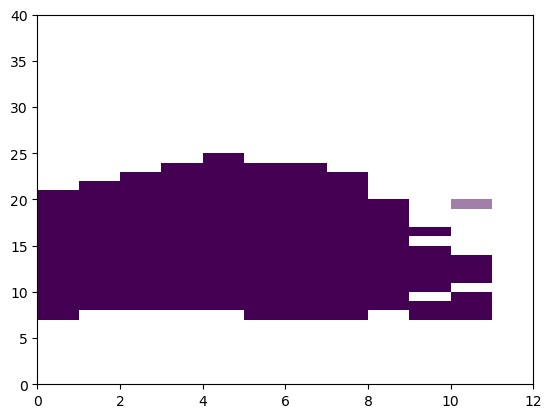

In [18]:
itrack = 10
# ds_wide_dx.CoreArea_up.isel(core=0, tracks=itrack).transpose().plot()
Wduration = int(ds_wide_dx.Wlifetime.isel(tracks=itrack).item()/time_res) + 1
Wmask = ds_wide_dx.Wmask.isel(tracks=itrack, times=slice(0, Wduration)).transpose()
Wmask_remove = ds_wide_dx.Wmask_remove.isel(tracks=itrack, times=slice(0, Wduration)).transpose()
plt.pcolormesh(Wmask)
plt.pcolormesh(Wmask_remove, alpha=0.5)

## Function to plot individual tracks of updrafts

In [19]:
def plot_tz_sample(xtime, height, da, da_mask, maxETH, cldTop, Wtime_startend, env_dict,
                   cldTop_fit=None, cldBase=None, cbase_depth=None, keep_flag=None, norm=None, arrow_axisfrac=-0.2,
                   xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None, legend_loc=None,
                   cmap=None, cblabels=None, cbticks=None, fontsize=None, figsize=None, figname=None, dpi=None):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    # mpl.rcParams['font.family'] = 'DejaVu Sans'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=dpi)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 2, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
    ax = plt.subplot(gs[0,0])
    cax = plt.subplot(gs[0,1])
    
    # Define line/symbol colors/sizes
    colors = {'ETH':'red', 'cldTop':'deepskyblue', 'cldBase':'cyan', 'cldTopFit':'dodgerblue',
              'LCL':'violet', 'LFC':'mediumorchid', 'ENV_time':'deeppink', 'time_s':'purple', 'time_e':'purple',
              'cldBase_layer':'gainsboro',}
    lws = {'ETH':3, 'cldTop':3, 'cldBase':2, 'LCL':1, 'LFC':1, 'cldBase_layer':1}
    markers = {'ETH':'D', 'cldTop':'o'}
    marker_sizes = {'ETH':40, 'cldTop':30}
    
    # Plot data
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', norm=norm, cmap=cmap)
    # Plot mask
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)
    # Updraft start/end time period
    ax.axvline(Wtime_startend['s'], lw=1, color=colors['time_s'])
    ax.axvline(Wtime_startend['e'], lw=1, color=colors['time_s'])
    ax.axvline(max(time_window), lw=1, ls=':', color=colors['time_e'])
    # ETH line
    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], lw=lws['ETH'], label='10dBZ ETH')
    # Max ETH
    idx_trackmaxETH = np.nanargmax(maxETH)
    time_trackmaxETH = xtime.values[idx_trackmaxETH]
    ax.scatter(time_trackmaxETH, np.nanmax(maxETH), s=marker_sizes['ETH'], c=colors['ETH'], marker=markers['ETH'], zorder=2)
    
    # cloud/updraft top line
    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], lw=lws['cldTop'], label='Updraft Top')
    # Max updraft top
    if (np.count_nonzero(~np.isnan(cldTop)) > 0):
        idx_trackmaxcldTop = np.nanargmax(cldTop)
        time_trackmaxcldTop = xtime.values[idx_trackmaxcldTop]
        ax.scatter(time_trackmaxcldTop, np.nanmax(cldTop), s=marker_sizes['cldTop'], c=colors['cldTop'], marker=markers['cldTop'], zorder=3)
    if cldBase is not None:
        cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], lw=lws['cldBase'], label='Updraft Base')
        # Median cloud base height
        median_cldBase = np.nanmedian(cldBase)
        median_cldBase_top = median_cldBase + cbase_depth
        # Plot a box for cloud base layer
        cbase_corners = [(Wtime_startend['s'],median_cldBase),(Wtime_startend['e'],median_cldBase),
                         (Wtime_startend['e'],median_cldBase_top),(Wtime_startend['s'],median_cldBase_top)]
        # Create a polygon patch with the corners
        polygon = mpl.patches.Polygon(cbase_corners, closed=True, edgecolor=colors['cldBase_layer'], facecolor='none', 
                                      lw=lws['cldBase_layer'], hatch='//', zorder=3)
        ax.add_patch(polygon)
        
    # cloud/updraft top fit line
    if cldTop_fit is not None:
        cldTop_fitline = ax.plot(xtime, cldTop_fit, color=colors['cldTopFit'], ls='--', label='Updraft Top (Fit)')
    
    # LCL/LFC lines
    LCL = env_dict['LCL']
    LFC = env_dict['LFC']
    ENV_time = env_dict['ENV_time']
    ax.axvline(ENV_time, color=colors['ENV_time'], lw=2)

    line_length = 50
    LCL_t0 = 0
    LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30
    LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    LCL_text_x = LCL_t0 + line_length / 2
    LCL_text_y = LCL-0.2
    LFC_text_x = LFC_t0 + line_length / 2
    LFC_text_y = LFC-0.2
    ax.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color=colors['LFC'], fontsize=fontsize)
    
    ax.legend(fontsize=fontsize*0.8, loc=legend_loc)
    # Draw an arrow below xaxis
    ax.annotate("", xy=(1, arrow_axisfrac), xycoords='axes fraction', xytext=(0, arrow_axisfrac), arrowprops=dict(facecolor='black'))
    # # Flag to
    # if keep_flag==True:
    #     track_flag = u'\u2713'
    #     track_color = 'green'
    # else:
    #     track_flag = u'\u2717'
    #     track_color = 'red'
    # if keep_flag is not None:
    #     ax.set_title(track_flag, loc='right', color=track_color)
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls=':', lw=0.7)
    # Colorbar
    cbar = plt.colorbar(pcm_da, cax=cax, label=cblabels, ticks=cbticks)
    cbar.minorticks_off()
    # cb = plt.colorbar(pcm_da, cax=cax, label=cblabels)
    
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

/var/folders/35/v1zkcq4s39z89sx72zf53t4h0000gn/T/ipykernel_17299/2836221421.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = copy.copy(mpl.cm.get_cmap(cmap))


/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0156.png


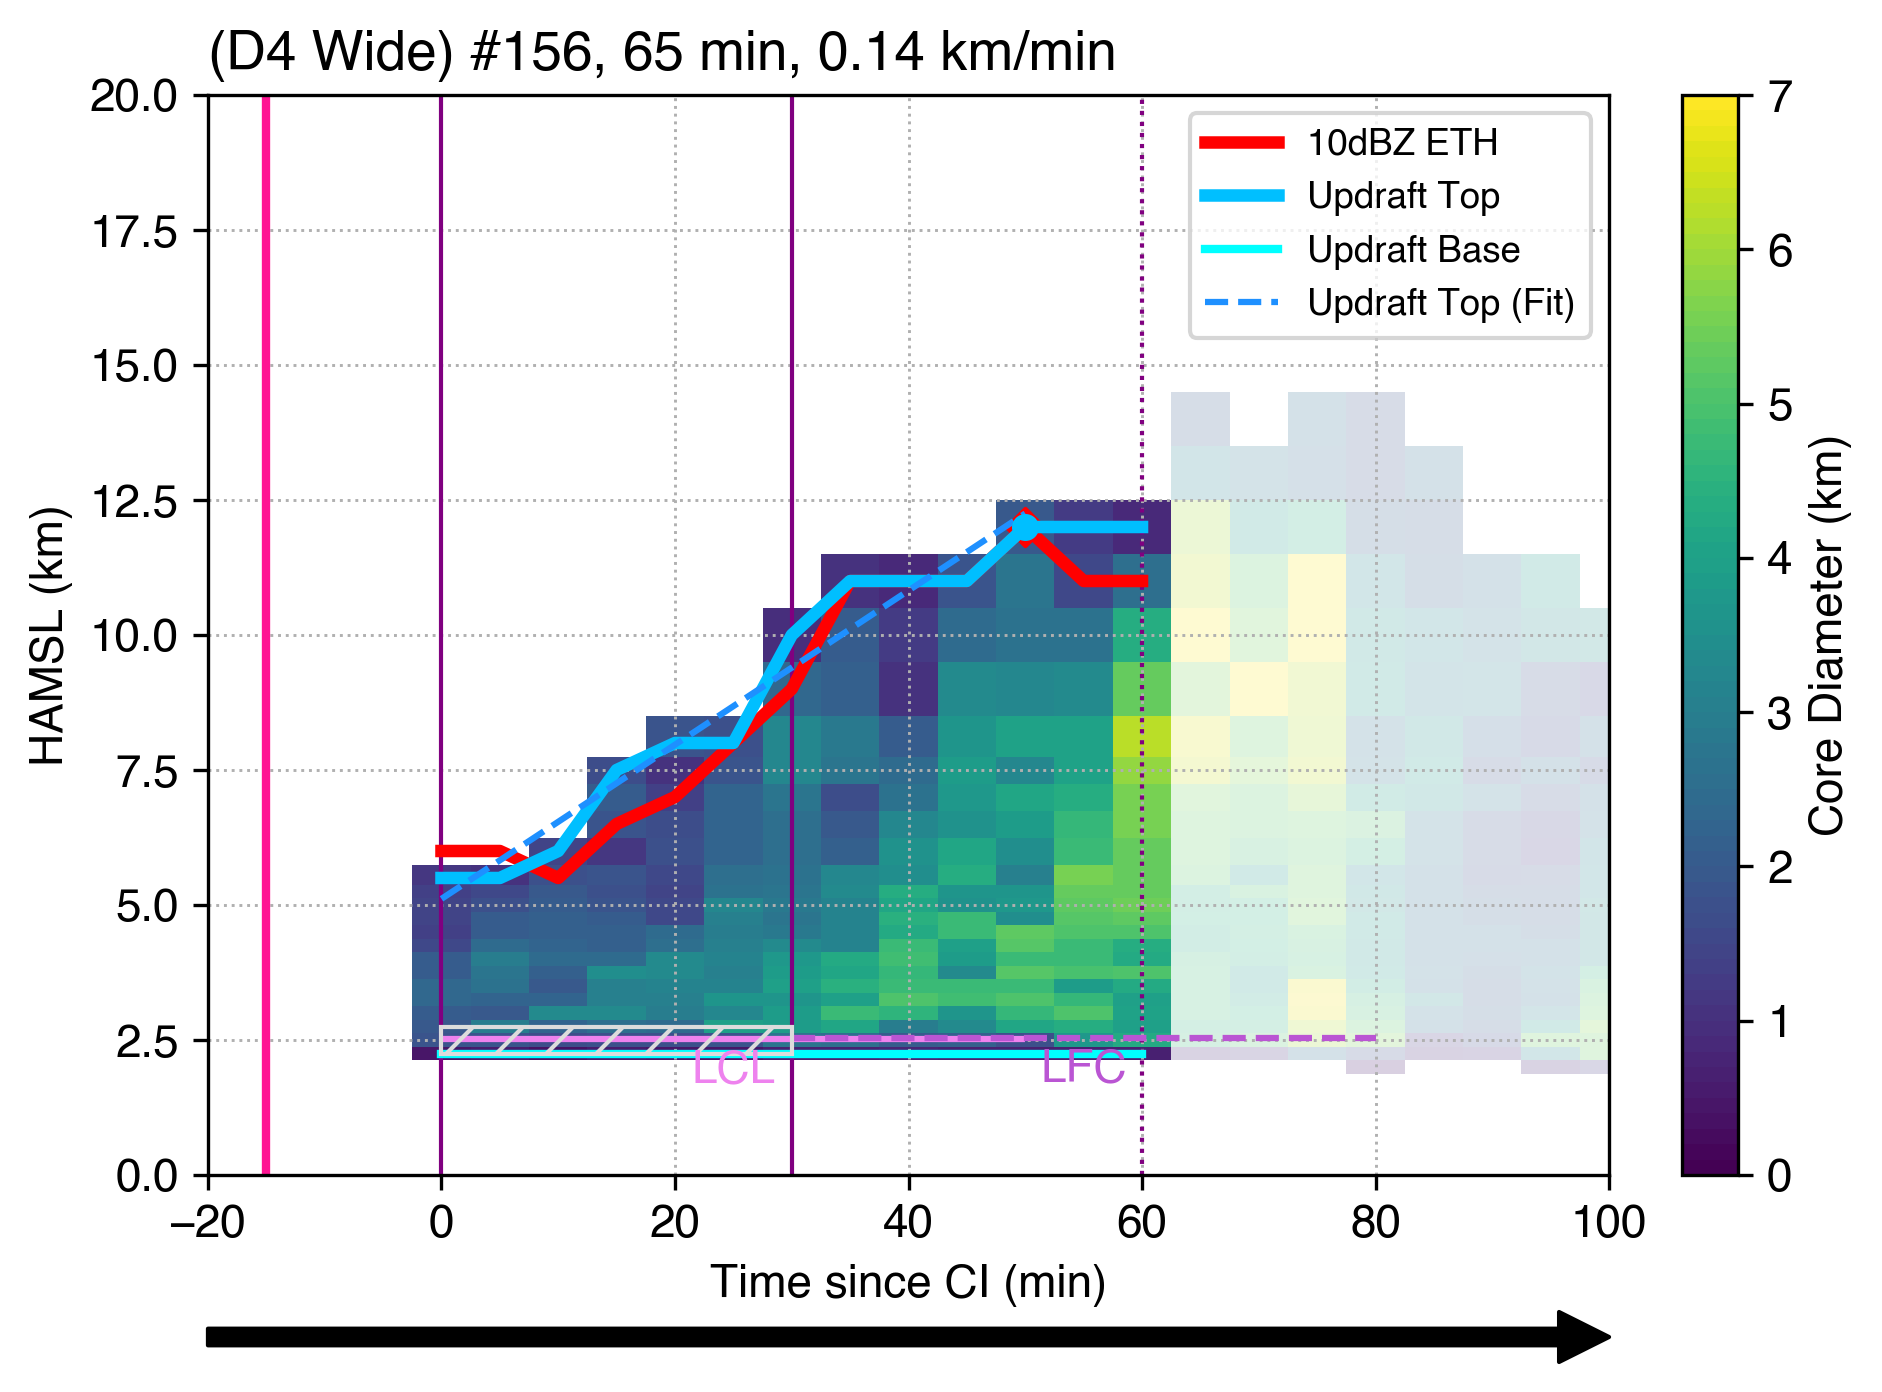

In [20]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# itrack = 0
# itrack = 79  # D4 (15 km ETH)
# itrack = 82  # D4 (15 km ETH)
# itrack = 90  # D4 (14 km ETH)
# itrack = 95  # D4 (13 km ETH)
itrack = 156  # D4 (13 km ETH)

# Updraft 
_da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
_da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
# 10dBZ ETH
_maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
_maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
# Filter updrafts above 10dBZ ETH + buffer
_da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

# Updraft quantities
_da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
_Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
_Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
_t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
_t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
# Limit updraft sampling end time to W_CI_time_end after CI
if _t_e > W_CI_time_end: _t_e = W_CI_time_end
_Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
# Convert HAMSL to AGL, then select a representative time before CI
LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
ENV_time = -15  # environment sample time [min]
_env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
_Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
_Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
_keep_flag = wide_tracks_dx.isel(tracks=itrack)

cmap = 'viridis'
cmap = copy.copy(mpl.cm.get_cmap(cmap))
# Shading levels
levels = np.arange(0, 7.01, 0.1)
cbticks = np.arange(0, 7.01, 1)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Axes
xlim = (-20,100)
# ylim = (0,12)
ylim = (0,20)
# title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
legend_loc = 'upper right'
# cblabels = 'Core Max W (m/s)'
# figbasename = 'CoreMaxW'
arrow_axisfrac = -0.15
cblabels = 'Core Diameter (km)'
figbasename = 'CoreDiam'
figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
figsize = (6,4)
fontsize = 11
dpi = 300

fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag, norm=norm,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc, arrow_axisfrac=arrow_axisfrac,
                     cmap=cmap, cblabels=cblabels, cbticks=cbticks, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
# plt.close(fig)
print(figname)

In [21]:
# time_coord.shape, height.shape, _da_mask.shape, _da.shape
# figdir
ntracks_wide_dx

195

In [22]:
# Set a seed for reproducibility
np.random.seed(10)

nsamples2plot = 200
# nsamples2plot = 50
if (nsamples2plot > ntracks_wide_dx): 
    nsamples2plot = ntracks_wide_dx
    tracks_random = np.arange(0, nsamples2plot)
else:
    tracks_random = np.random.randint(0, ds_wide_dx.sizes['tracks'], nsamples2plot)

print(len(tracks_random))
tracks_random

195


array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

### Plot wide cell updraft core diameter

In [23]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_wide_dx): nsamples2plot = ntracks_wide_dx
# tracks_random = np.random.randint(0, ds_wide_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    # Updraft 
    _da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = wide_tracks_dx.isel(tracks=itrack)

    # Axes
    # xlim = (-5,100)
    xlim = (-20,100)
    ylim = (0,20)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    # cblabels = 'Core Max W (m/s)'
    # figbasename = 'CoreMaxW'
    cblabels = 'Core Diameter (km)'
    figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)

/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0000.png
/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0001.png
/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0002.png
/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0003.png
/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0004.png
/Users/feng045/Library/CloudStorage/Dropbox/Work/Results/ICLASS/CACTI/LASSO/LES/figures_avgenv20km/updraft_tracks_narrowwide_CI30min/CoreDiam_d4_wide_0005.png
/Users/feng045/Library/CloudStorage/Dropbox/Wo

### Plot wide cell updraft speed

In [ ]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in tracks_random[0:1]:
    # Updraft 
    _da_Wmax = ds_wide_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_wide_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_wide_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)
    _da_Wmax = _da_Wmax.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_wide_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_wide_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_wide_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_wide_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_wide_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_wide_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_wide_dx.LCL_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_wide_dx.LFC_height_mu + ds_wide_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_wide_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_wide_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = wide_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,20)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Wide) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Diameter (km)'
    # figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_wide_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_Wmax, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)

In [ ]:
dsnms_dx.CoreBuoyTrho_up.attrs

In [ ]:
_da_CoreBuoyTrho = ds_narrow_dx.CoreBuoyTrho_up.isel(tracks=itrack).transpose()
_da_CoreBuoyTrho.isel(times=slice(0,10)).plot()

In [ ]:
ds_narrow_dx.CoreBuoyTrho_up.dims

### Plot narrow cell buoyancy

In [ ]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

itrack = 156  # D4 (15 km ETH)

# Updraft 
# _da_Wmax = ds_narrow_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
_da_WDiam = 2 * np.sqrt(ds_narrow_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
_da_CoreBuoyTrho = ds_narrow_dx.CoreBuoyTrho_up.isel(tracks=itrack).transpose()
# 10dBZ ETH
_maxETH = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
_maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
# Filter updrafts above 10dBZ ETH + buffer
# _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)
_da_CoreBuoyTrho = _da_CoreBuoyTrho.where(height <= _maxETH_full+ETH_buffer)

# Updraft quantities
_da_mask = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
_Wtop = ds_narrow_dx.Wtop.isel(tracks=itrack)
_Wbase = ds_narrow_dx.Wbase.isel(tracks=itrack)
_t_s = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
_t_e = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
_Wlifetime = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
# Convert HAMSL to AGL, then select a representative time before CI
LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
ENV_time = -15  # environment sample time [min]
_env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
_Wtop_fit = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
_Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
_keep_flag = narrow_tracks_dx.isel(tracks=itrack)

cmap = 'plasma'
cmap = copy.copy(mpl.cm.get_cmap(cmap))
# Shading levels
# levels = np.arange(0, 7.01, 0.1)
# cbticks = np.arange(0, 7.01, 1)
levels = np.linspace(np.nanmin(_da_CoreBuoyTrho), np.nanmax(_da_CoreBuoyTrho), 41)
cbticks = None
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

# Axes
xlim = (-20,100)
# ylim = (0,12)
ylim = (0,10)
# title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
title = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
legend_loc = 'upper right'
# cblabels = 'Core Max W (m/s)'
# figbasename = 'CoreMaxW'
arrow_axisfrac = -0.15
cblabels = 'Core Buoyancy (m/s²)'
figbasename = 'CoreBuoyTrho'
figname = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
figsize = (6,4)
fontsize = 11
dpi = 300

fig = plot_tz_sample(xtime, height, _da_CoreBuoyTrho, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                     cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag, norm=norm,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc, arrow_axisfrac=arrow_axisfrac,
                     cmap=cmap, cblabels=cblabels, cbticks=cbticks, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
# plt.close(fig)
print(figname)

In [ ]:
_da_CoreBuoyTrho.max(dim='times').plot()

In [ ]:
def buoy_slope(buoy_profile, z):
    """
    Compute updraft buoyancy profile reduction rate from in-cloud maximum to
    cloud-top minimum using a linear fit.

    Parameters
    ----------
    buoy_profile : array-like, shape (nz,)
        1D buoyancy profile (e.g., max over times for one track).
    z : array-like, shape (nz,)
        Height levels (km) corresponding to buoy_profile.

    Returns
    -------
    dict or None
        Keys:
          'buoy_max'   : maximum buoyancy value (m/s²)
          'z_max'      : height of buoy_max (km)
          'buoy_min'   : minimum buoyancy above buoy_max (m/s²)
          'z_min'      : height of buoy_min (km)
          'poly_coeffs': np.polyfit coefficients [slope (m/s²/km), intercept]
        Returns None if the profile has insufficient valid data.
    """
    buoy_arr = np.asarray(buoy_profile, dtype=float)
    z_arr    = np.asarray(z, dtype=float)

    valid = ~np.isnan(buoy_arr)
    if valid.sum() < 2:
        return None

    buoy_v = buoy_arr[valid]
    z_v    = z_arr[valid]

    # Max buoyancy and its z level
    idx_max  = np.argmax(buoy_v)
    buoy_max = float(buoy_v[idx_max])
    z_max    = float(z_v[idx_max])

    # Minimum buoyancy strictly above the max level
    above_mask = z_v > z_max
    if above_mask.sum() == 0:
        return None
    buoy_above = buoy_v[above_mask]
    z_above    = z_v[above_mask]
    idx_min    = np.argmin(buoy_above)
    buoy_min   = float(buoy_above[idx_min])
    z_min      = float(z_above[idx_min])

    # Linear fit between z_max and z_min (inclusive)
    between = (z_v >= z_max) & (z_v <= z_min)
    if between.sum() < 2:
        return None
    poly_coeffs = np.polyfit(z_v[between], buoy_v[between], 1)  # [slope, intercept]

    return {
        'buoy_max'   : buoy_max,
        'z_max'      : z_max,
        'buoy_min'   : buoy_min,
        'z_min'      : z_min,
        'poly_coeffs': poly_coeffs,
    }


In [ ]:
def plot_tz_sample_wbuoy(xtime, height, da, da_mask, maxETH, cldTop, Wtime_startend, env_dict,
                         buoy_profile_max, buoy_slope_dict,
                         cldTop_fit=None, cldBase=None, cbase_depth=None, keep_flag=None, norm=None, arrow_axisfrac=-0.2,
                         xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None, legend_loc=None,
                         cmap=None, cblabels=None, cbticks=None, fontsize=None, figsize=None, figname=None, dpi=None):
    """
    Like plot_tz_sample but with an extra narrow buoyancy-profile panel
    (shared y-axis) between the pcolormesh and the colorbar.

    Extra parameters
    ----------------
    buoy_profile_max : array-like, shape (nz,)
        Max-over-times buoyancy profile for the track.
    buoy_slope_dict : dict or None
        Output of buoy_slope(); set to None to skip the overlay.
    """
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=dpi)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 3,
                           height_ratios=np.repeat(1, nrows).tolist(),
                           width_ratios=[1, 0.22, 0.04])
    gs.update(left=0.05, right=0.97, bottom=0.05, top=0.95, wspace=0.03, hspace=0.15)
    ax      = plt.subplot(gs[0, 0])
    ax_buoy = plt.subplot(gs[0, 1], sharey=ax)
    cax     = plt.subplot(gs[0, 2])

    # Remove y-axis labels/ticks from profile panel to minimise visual gap
    plt.setp(ax_buoy.get_yticklabels(), visible=False)
    ax_buoy.tick_params(axis='y', which='both', length=0)

    # ── colours / line widths (same as plot_tz_sample) ──────────────────────
    colors = {'ETH':'red', 'cldTop':'deepskyblue', 'cldBase':'cyan', 'cldTopFit':'dodgerblue',
              'LCL':'violet', 'LFC':'mediumorchid', 'ENV_time':'deeppink',
              'time_s':'purple', 'time_e':'purple', 'cldBase_layer':'gainsboro'}
    lws          = {'ETH':3, 'cldTop':3, 'cldBase':2, 'LCL':1, 'LFC':1, 'cldBase_layer':1}
    markers      = {'ETH':'D', 'cldTop':'o'}
    marker_sizes = {'ETH':40, 'cldTop':30}

    # ── pcolormesh panel ─────────────────────────────────────────────────────
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', norm=norm, cmap=cmap)
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)

    ax.axvline(Wtime_startend['s'], lw=1, color=colors['time_s'])
    ax.axvline(Wtime_startend['e'], lw=1, color=colors['time_s'])
    ax.axvline(max(time_window), lw=1, ls=':', color=colors['time_e'])

    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], lw=lws['ETH'], label='10dBZ ETH')
    idx_trackmaxETH  = np.nanargmax(maxETH)
    time_trackmaxETH = xtime.values[idx_trackmaxETH]
    ax.scatter(time_trackmaxETH, np.nanmax(maxETH),
               s=marker_sizes['ETH'], c=colors['ETH'], marker=markers['ETH'], zorder=2)

    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], lw=lws['cldTop'], label='Updraft Top')
    if np.count_nonzero(~np.isnan(cldTop)) > 0:
        idx_trackmaxcldTop  = np.nanargmax(cldTop)
        time_trackmaxcldTop = xtime.values[idx_trackmaxcldTop]
        ax.scatter(time_trackmaxcldTop, np.nanmax(cldTop),
                   s=marker_sizes['cldTop'], c=colors['cldTop'], marker=markers['cldTop'], zorder=3)

    if cldBase is not None:
        cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], lw=lws['cldBase'], label='Updraft Base')
        median_cldBase     = np.nanmedian(cldBase)
        median_cldBase_top = median_cldBase + cbase_depth
        cbase_corners = [(Wtime_startend['s'], median_cldBase),  (Wtime_startend['e'], median_cldBase),
                         (Wtime_startend['e'], median_cldBase_top), (Wtime_startend['s'], median_cldBase_top)]
        polygon = mpl.patches.Polygon(cbase_corners, closed=True,
                                      edgecolor=colors['cldBase_layer'], facecolor='none',
                                      lw=lws['cldBase_layer'], hatch='//', zorder=3)
        ax.add_patch(polygon)

    if cldTop_fit is not None:
        cldTop_fitline = ax.plot(xtime, cldTop_fit, color=colors['cldTopFit'], ls='--', label='Updraft Top (Fit)')

    LCL      = env_dict['LCL']
    LFC      = env_dict['LFC']
    ENV_time = env_dict['ENV_time']
    ax.axvline(ENV_time, color=colors['ENV_time'], lw=2)
    line_length = 50
    LCL_t0 = 0;  LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30; LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    ax.text(LCL_t0 + line_length/2, LCL - 0.2, 'LCL', ha='center', va='top',
            color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_t0 + line_length/2, LFC - 0.2, 'LFC', ha='center', va='top',
            color=colors['LFC'], fontsize=fontsize)

    ax.legend(fontsize=fontsize * 0.8, loc=legend_loc)
    ax.annotate("", xy=(1, arrow_axisfrac), xycoords='axes fraction',
                xytext=(0, arrow_axisfrac), arrowprops=dict(facecolor='black'))
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls=':', lw=0.7)

    # ── buoyancy profile panel ───────────────────────────────────────────────
    buoy_vals = np.asarray(buoy_profile_max, dtype=float)
    z_vals    = np.asarray(height, dtype=float)
    ax_buoy.plot(buoy_vals, z_vals, color='black', lw=1.5)
    ax_buoy.set_ylim(ylim[0], ylim[1])
    ax_buoy.set_xlabel('Buoy.\n(m/s²)', fontsize=fontsize * 0.8)
    ax_buoy.grid(ls=':', lw=0.7)

    if buoy_slope_dict is not None:
        bmax   = buoy_slope_dict['buoy_max']
        zmax   = buoy_slope_dict['z_max']
        bmin   = buoy_slope_dict['buoy_min']
        zmin   = buoy_slope_dict['z_min']
        coeffs = buoy_slope_dict['poly_coeffs']
        slope_val = coeffs[0]

        # Filled circles at max (red) and min (blue) buoyancy levels
        ax_buoy.scatter(bmax, zmax, s=50, c='red',  zorder=5)
        ax_buoy.scatter(bmin, zmin, s=50, c='blue', zorder=5)

        # Linear fit line (dashed)
        z_fit    = np.linspace(zmax, zmin, 100)
        buoy_fit = np.polyval(coeffs, z_fit)
        ax_buoy.plot(buoy_fit, z_fit, color='dimgray', ls='--', lw=1.5)

        ax_buoy.set_title(f'{slope_val:.3f} m/s²/km', fontsize=fontsize * 0.8)

    # ── colorbar ─────────────────────────────────────────────────────────────
    cb = plt.colorbar(pcm_da, cax=cax, label=cblabels, ticks=cbticks)

    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig


In [ ]:
ETH_buffer = dsnms_dx.attrs['ETH_buffer']
cbase_depth = dsnms_dx.attrs['cbase_depth']

itrack = 156  # D4 (15 km ETH)

# Updraft buoyancy (z × times) for this track
_da_CoreBuoyTrho = ds_narrow_dx.CoreBuoyTrho_up.isel(tracks=itrack).transpose()
# 10 dBZ ETH
_maxETH      = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where(
                   (xtime >= min(time_window)) & (xtime <= max(time_window)))
_maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
# Mask buoyancy above ETH + buffer
_da_CoreBuoyTrho = _da_CoreBuoyTrho.where(height <= _maxETH_full + ETH_buffer)

# Max buoyancy profile: reduce 'times' dimension by taking max → shape (nz,)
_buoy_max_profile = _da_CoreBuoyTrho.max(dim='times')

# Compute buoyancy slope (max → cloud-top min linear reduction rate)
_bslope_dict = buoy_slope(_buoy_max_profile.values, height.values)
print('buoy_slope result:', _bslope_dict)

# Remaining track quantities
_da_mask       = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
_Wtop          = ds_narrow_dx.Wtop.isel(tracks=itrack)
_Wbase         = ds_narrow_dx.Wbase.isel(tracks=itrack)
_t_s           = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
_t_e           = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
_Wlifetime     = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
_Wtime_startend = {'s': _t_s, 'e': _t_e}
_WtopMax       = _Wtop.max(dim='times').item()
LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
ENV_time = -15
_env_dict  = {'LCL': LCL, 'LFC': LFC, 'ENV_time': ENV_time}
_Wtop_fit  = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
_Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
_keep_flag  = narrow_tracks_dx.isel(tracks=itrack)

cmap = 'plasma'
cmap = copy.copy(mpl.cm.get_cmap(cmap))
levels  = np.linspace(np.nanmin(_da_CoreBuoyTrho), np.nanmax(_da_CoreBuoyTrho), 41)
cbticks = None
norm    = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

xlim         = (-20, 100)
ylim         = (0, 10)
title        = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
xlabel       = 'Time since CI (min)'
ylabel       = 'HAMSL (km)'
legend_loc   = 'upper right'
arrow_axisfrac = -0.15
cblabels     = 'Core Buoyancy (m/s²)'
figbasename  = 'CoreBuoyTrho_profile_'
figname      = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
figsize      = (7.5, 4)
fontsize     = 11
dpi          = 300

fig = plot_tz_sample_wbuoy(
    xtime, height, _da_CoreBuoyTrho, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
    _buoy_max_profile, _bslope_dict,
    cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag, norm=norm,
    xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc,
    arrow_axisfrac=arrow_axisfrac, cmap=cmap, cblabels=cblabels, cbticks=cbticks,
    fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
# plt.close(fig)
print(figname)


In [ ]:
# Set a seed for reproducibility
np.random.seed(10)
nsamples2plot = 200
if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)
tracks_random

In [ ]:
# Loop over each track to plot
for itrack in tracks_random:

    # Updraft buoyancy (z × times) for this track
    _da_CoreBuoyTrho = ds_narrow_dx.CoreBuoyTrho_up.isel(tracks=itrack).transpose()
    # 10 dBZ ETH
    _maxETH      = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where(
                    (xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
    # Mask buoyancy above ETH + buffer
    _da_CoreBuoyTrho = _da_CoreBuoyTrho.where(height <= _maxETH_full + ETH_buffer)

    # Max buoyancy profile: reduce 'times' dimension by taking max → shape (nz,)
    _buoy_max_profile = _da_CoreBuoyTrho.max(dim='times')

    # Compute buoyancy slope (max → cloud-top min linear reduction rate)
    _bslope_dict = buoy_slope(_buoy_max_profile.values, height.values)
    print('buoy_slope result:', _bslope_dict)

    # Remaining track quantities
    _da_mask       = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop          = ds_narrow_dx.Wtop.isel(tracks=itrack)
    _Wbase         = ds_narrow_dx.Wbase.isel(tracks=itrack)
    _t_s           = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e           = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime     = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s': _t_s, 'e': _t_e}
    _WtopMax       = _Wtop.max(dim='times').item()
    LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15
    _env_dict  = {'LCL': LCL, 'LFC': LFC, 'ENV_time': ENV_time}
    _Wtop_fit  = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag  = narrow_tracks_dx.isel(tracks=itrack)

    cmap = 'plasma'
    cmap = copy.copy(mpl.cm.get_cmap(cmap))
    levels  = np.linspace(np.nanmin(_da_CoreBuoyTrho), np.nanmax(_da_CoreBuoyTrho), 41)
    cbticks = None
    norm    = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)

    xlim         = (-20, 100)
    ylim         = (0, 10)
    title        = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel       = 'Time since CI (min)'
    ylabel       = 'HAMSL (km)'
    legend_loc   = 'upper right'
    arrow_axisfrac = -0.15
    cblabels     = 'Core Buoyancy (m/s²)'
    figbasename  = 'CoreBuoyTrho_profile'
    figname      = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
    figsize      = (7.5, 4)
    fontsize     = 11
    dpi          = 300

    fig = plot_tz_sample_wbuoy(
        xtime, height, _da_CoreBuoyTrho, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
        _buoy_max_profile, _bslope_dict,
        cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag, norm=norm,
        xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel, legend_loc=legend_loc,
        arrow_axisfrac=arrow_axisfrac, cmap=cmap, cblabels=cblabels, cbticks=cbticks,
        fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)


In [ ]:
# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
# tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in range(0, 1):
    # Updraft 
    _da_Wmax = ds_narrow_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_narrow_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_narrow_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_narrow_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = narrow_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    # cblabels = 'Core Max W (m/s)'
    # figbasename = 'CoreMaxW'
    cblabels = 'Core Diameter (km)'
    figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    print(figname)
    fig = plot_tz_sample(xtime, height, _da_WDiam, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)

In [ ]:
# ETH_buffer = dsnms_dx.attrs['ETH_buffer']
# cbase_depth = dsnms_dx.attrs['cbase_depth']

# # Set a seed for reproducibility
# np.random.seed(10)
# nsamples2plot = 100
# if (nsamples2plot > ntracks_narrow_dx): nsamples2plot = ntracks_narrow_dx
# tracks_random = np.random.randint(0, ds_narrow_dx.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
# for itrack in tracks_random[0:1]:
    # Updraft 
    _da_Wmax = ds_narrow_dx.CoreMaxW_up.isel(tracks=itrack).transpose()
    _da_WDiam = 2 * np.sqrt(ds_narrow_dx.CoreArea_up.isel(tracks=itrack).transpose() / np.pi)
    # 10dBZ ETH
    _maxETH = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack).where((xtime >= min(time_window)) & (xtime <= max(time_window)))
    _maxETH_full = ds_narrow_dx.maxETH_10dbz.isel(tracks=itrack)
    # Filter updrafts above 10dBZ ETH + buffer
    _da_WDiam = _da_WDiam.where(height <= _maxETH_full+ETH_buffer)
    _da_Wmax = _da_Wmax.where(height <= _maxETH_full+ETH_buffer)

    # Updraft quantities
    _da_mask = ds_narrow_dx.Wmask_remove.isel(tracks=itrack).transpose()
    _Wtop = ds_narrow_dx.Wtop.isel(tracks=itrack)
    _Wbase = ds_narrow_dx.Wbase.isel(tracks=itrack)
    _t_s = ds_narrow_dx.Wtime_start.isel(tracks=itrack) * time_res
    _t_e = ds_narrow_dx.Wtime_end.isel(tracks=itrack) * time_res
    _Wlifetime = ds_narrow_dx.Wlifetime.isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    # Convert HAMSL to AGL, then select a representative time before CI
    LCL = (ds_narrow_dx.LCL_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    LFC = (ds_narrow_dx.LFC_height_mu + ds_narrow_dx.Z_surface).isel(tracks=itrack) / 1000.
    ENV_time = -15  # environment sample time [min]
    _env_dict = {'LCL':LCL, 'LFC':LFC, 'ENV_time':ENV_time}
    _Wtop_fit = ds_narrow_dx.Wtop_fit.isel(tracks=itrack)
    _Wtop_slope = ds_narrow_dx.Wtop_slope.isel(tracks=itrack)
    _keep_flag = narrow_tracks_dx.isel(tracks=itrack)

    # Axes
    xlim = (-5,100)
    ylim = (0,12)
    # title = f'(dx) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km, {_Wtop_slope:}'
    title = f'({domain_name.upper()} Narrow) #{itrack}, {_Wlifetime:.0f} min, {_Wtop_slope:.2f} km/min'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Diameter (km)'
    # figbasename = 'CoreDiam'
    figname = f'{figdir}{figbasename}_{domain_name}_narrow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 11
    dpi = 200

    fig = plot_tz_sample(xtime, height, _da_Wmax, _da_mask, _maxETH, _Wtop, _Wtime_startend, _env_dict,
                         cldTop_fit=_Wtop_fit, cldBase=_Wbase, cbase_depth=cbase_depth, keep_flag=_keep_flag,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname, dpi=dpi)
    plt.close(fig)
    print(figname)